# Count data: Poisson, overdispersion, and the negative binomial

Why the Poisson distribution is the natural first model for counts, the strong assumption it bakes in (mean = variance), how to detect when real count data violate it (overdispersion, the common case), and the standard fix - the negative binomial - plus a note on zero-inflation. The throughline: a model's assumptions are testable, and counts almost always need more than Poisson.


## The Poisson and its rigid mean-variance link

The Poisson distribution $P(X=k)=e^{-\lambda}\lambda^k/k!$ has the defining property that its mean and
variance are equal: $\mathbb E[X]=\mathrm{Var}(X)=\lambda$. This is not a free choice but a constraint of
the model, and it is the first thing to check on count data.

Definition (index of dispersion). $D=\mathrm{Var}(X)/\mathbb E[X]$. Under the Poisson $D=1$; $D>1$ is
overdispersion (extra variability, the common case for real counts), $D<1$ underdispersion. A sample
estimate well above one signals that the Poisson is too rigid.

The usual cause of overdispersion is unmodeled heterogeneity: the rate $\lambda$ itself varies across
units. Mixing the Poisson rate over a distribution produces a count law with the same mean but a larger
variance, and the natural conjugate choice gives a distribution in closed form.

## The negative binomial as a gamma-Poisson mixture

Theorem (gamma mixing yields the negative binomial). If $\lambda\sim\mathrm{Gamma}(r,\,\theta)$ with
shape $r$ and mean $\mu=r\theta$, and $X\mid\lambda\sim\mathrm{Poisson}(\lambda)$, then marginally $X$ is
negative binomial with
$$\mathbb E[X]=\mu, \qquad \mathrm{Var}(X)=\mu + \mu^2/r > \mu.$$

Proof. Integrate the rate out:
$$P(X=k)=\int_0^\infty \frac{e^{-\lambda}\lambda^k}{k!}\,\frac{\lambda^{r-1}e^{-\lambda/\theta}}{\theta^r\Gamma(r)}\,d\lambda
   = \frac{\theta^k}{k!\,\theta^r\Gamma(r)}\int_0^\infty \lambda^{k+r-1}e^{-\lambda(1+1/\theta)}\,d\lambda.$$
The integral is $\Gamma(k+r)\,(1+1/\theta)^{-(k+r)}$. Collecting terms gives the negative-binomial mass
function with success probability $p=1/(1+\theta)$. For the moments, the law of total variance gives
$\mathrm{Var}(X)=\mathbb E[\mathrm{Var}(X\mid\lambda)]+\mathrm{Var}(\mathbb E[X\mid\lambda])
=\mathbb E[\lambda]+\mathrm{Var}(\lambda)=\mu+\mu^2/r$. $\quad\blacksquare$

The extra term $\mu^2/r$ is the overdispersion; as $r\to\infty$ the gamma concentrates and the negative
binomial returns to the Poisson. A separate mechanism, zero-inflation, mixes a point mass at zero with a
count law to handle an excess of structural zeros.

## Testing for overdispersion, and the cost of ignoring it

Theorem (score test for overdispersion; Dean-Lawless). Under the Poisson null against a negative-binomial
alternative, the statistic
$$T = \frac{\sum_i\big[(y_i-\hat\lambda)^2 - y_i\big]}{\hat\lambda\sqrt{2n}}$$
is asymptotically standard normal, and large positive values reject equidispersion. It is a Lagrange
multiplier test, derived from the score of the dispersion parameter at the Poisson boundary.

Counterexample (Poisson standard errors lie under overdispersion). Fitting a Poisson to overdispersed
data still estimates the mean consistently, but the reported standard error
$\mathrm{SE}(\hat\mu)=\sqrt{\hat\mu/n}$ assumes $\mathrm{Var}=\mu$. When the truth has
$\mathrm{Var}=\mu+\mu^2/r$, this understates the real variability by the factor $\sqrt{1+\mu/r}$, so Wald
confidence intervals are too narrow and cover the truth far less than their nominal rate. The practical
damage is anti-conservative inference: spurious significance. We quantify both the gamma-Poisson identity
and the broken coverage below; the fix is the negative binomial (or a quasi-Poisson variance inflation).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import PoissonEstimator, NegativeBinomialEstimator
from mixle.inference.estimation import optimize
rng = np.random.RandomState(0)

## 1. The Poisson and its one assumption

The Poisson is the canonical model for "how many events in a fixed window": $P(k)=\lambda^k e^{-\lambda}/k!$. Its MLE rate is just the sample mean. But it carries one rigid assumption - equidispersion: $\mathrm{Var}=\mathbb{E}=\lambda$. Real counts (claims per customer, defects per unit, words per document) are usually more variable than that because the rate itself fluctuates across units. We simulate genuinely overdispersed counts (a negative binomial) and first fit a Poisson to expose the problem.


In [2]:
# overdispersed counts: a negative binomial truth (rate varies across units)
data = [float(x) for x in rng.negative_binomial(4, 0.4, 3000)]
emp_mean, emp_var = np.mean(data), np.var(data)
print('data: mean=%.2f  variance=%.2f  index of dispersion (var/mean)=%.2f' % (emp_mean, emp_var, emp_var / emp_mean))

pois = optimize(data, PoissonEstimator(), max_its=1, rng=rng, print_iter=100)
print('Poisson MLE: lambda=%.2f  -> it ASSUMES variance = %.2f (way below the data)' % (pois.lam, pois.lam))

data: mean=5.89  variance=14.77  index of dispersion (var/mean)=2.51
Poisson MLE: lambda=5.89  -> it ASSUMES variance = 5.89 (way below the data)


## 2. Detecting and fixing overdispersion

The index of dispersion $D=\mathrm{Var}/\mathbb{E}$ is the diagnostic: $D\approx 1$ is Poisson-consistent, $D\gg 1$ is overdispersion. Ours is well above 1, so Poisson will fit the center but badly understate the spread and the tail. The negative binomial adds a dispersion parameter - it is a Poisson whose rate is itself Gamma-distributed (a continuous mixture of Poissons), so its variance exceeds its mean. We fit both and overlay their PMFs on the data.


Negative binomial MLE: r=3.93 p=0.40  -> mean=5.89 variance=14.69 (matches the data)


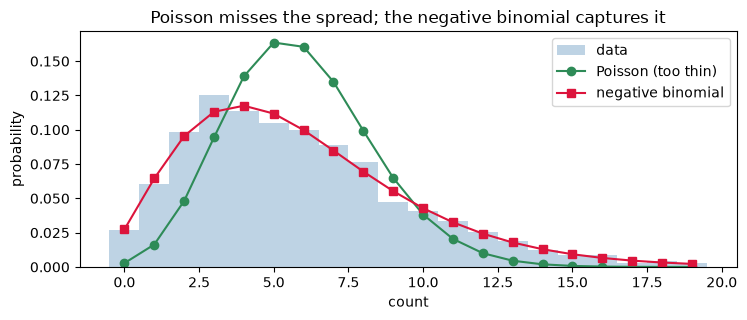

In [3]:
nb = optimize(data, NegativeBinomialEstimator(), max_its=40, rng=rng, print_iter=100)
nb_mean = nb.r * (1 - nb.p) / nb.p
nb_var = nb.r * (1 - nb.p) / nb.p ** 2
print('Negative binomial MLE: r=%.2f p=%.2f  -> mean=%.2f variance=%.2f (matches the data)' % (nb.r, nb.p, nb_mean, nb_var))

ks = np.arange(0, int(np.percentile(data, 99.5)) + 1)
pois_pmf = np.exp([pois.log_density(float(k)) for k in ks])
nb_pmf = np.exp([nb.log_density(float(k)) for k in ks])
fig, ax = plt.subplots(figsize=(7.5, 3.3))
ax.hist(data, bins=np.arange(-0.5, ks[-1] + 1.5), density=True, alpha=0.35, color='steelblue', label='data')
ax.plot(ks, pois_pmf, 'o-', color='seagreen', label='Poisson (too thin)')
ax.plot(ks, nb_pmf, 's-', color='crimson', label='negative binomial')
ax.set_xlabel('count'); ax.set_ylabel('probability'); ax.legend(); ax.set_title('Poisson misses the spread; the negative binomial captures it')
plt.tight_layout(); plt.show()

The Poisson curve is too peaked - it under-predicts both the zeros and the long right tail, exactly the signature of forcing variance to equal the mean. The negative binomial tracks the histogram. We can confirm with held-out log-likelihood, the model-agnostic verdict.


In [4]:
test = [float(x) for x in rng.negative_binomial(4, 0.4, 3000)]
ll = lambda m: float(np.sum(m.seq_log_density(m.dist_to_encoder().seq_encode(test))))
print('held-out log-likelihood  Poisson: %.0f   negative binomial: %.0f' % (ll(pois), ll(nb)))
print('the negative binomial wins by %.0f nats' % (ll(nb) - ll(pois)))

held-out log-likelihood  Poisson: -8840   negative binomial: -8013
the negative binomial wins by 827 nats


## A formal overdispersion test

Eyeballing the dispersion ratio is not enough - report a p-value. For a constant-mean Poisson the score/Lagrange-multiplier test (Cameron-Trivedi; Dean-Lawless) uses the statistic $T=\sum_i[(y_i-\hat\lambda)^2-y_i]\,/\,(\hat\lambda\sqrt{2n})$, which is $\approx\mathcal N(0,1)$ under equidispersion and large under overdispersion. We compute it for our data and, as a check, on genuinely-Poisson data (where it should not reject).


In [5]:
from scipy.stats import norm
def dispersion_test(y, lam):
    y = np.asarray(y, float); n = len(y)
    T = np.sum((y - lam) ** 2 - y) / (lam * np.sqrt(2 * n))
    return T, norm.sf(T)                                  # one-sided p-value (H1: overdispersed)
T, p = dispersion_test(data, pois.lam)
print('our data        : score stat T=%.1f  p=%.2e  -> reject equidispersion' % (T, p))
truep = rng.poisson(5.0, len(data)).astype(float)
T0, p0 = dispersion_test(truep, truep.mean())
print('true-Poisson data: score stat T=%.2f  p=%.2f  -> correctly does NOT reject' % (T0, p0))

our data        : score stat T=58.5  p=0.00e+00  -> reject equidispersion
true-Poisson data: score stat T=0.43  p=0.33  -> correctly does NOT reject


## Illustration: the mixture identity and the coverage failure

First we confirm that a gamma-mixed Poisson is exactly negative binomial, with variance above the mean.
Then we show that fitting a Poisson to overdispersed data produces confidence intervals that cover the
true mean far less than the nominal 95 percent, because the Poisson standard error is too small.

In [6]:
from scipy import stats as _st
rng = np.random.RandomState(0)
mu, r = 5.0, 2.0                                            # mean 5, dispersion r
lam = rng.gamma(shape=r, scale=mu / r, size=200000)
x = rng.poisson(lam)                                       # gamma-Poisson mixture
nb = _st.nbinom(n=r, p=r / (r + mu))                       # the claimed negative binomial
print('gamma-Poisson  mean=%.2f var=%.2f' % (x.mean(), x.var()))
print('negative binom mean=%.2f var=%.2f  (theory var = mu + mu^2/r = %.2f)' % (nb.mean(), nb.var(), mu + mu ** 2 / r))
print('max |empirical pmf - nbinom pmf| over k=0..20 = %.4f  (they match)' %
      np.max(np.abs(np.bincount(x, minlength=21)[:21] / len(x) - nb.pmf(np.arange(21)))))
# coverage of the Poisson Wald interval for the mean, on overdispersed data
n = 100; cover = 0; reps = 4000
for _ in range(reps):
    lam_s = rng.gamma(r, mu / r, n); xs = rng.poisson(lam_s)
    mhat = xs.mean(); se = np.sqrt(mhat / n)               # Poisson SE (wrong here)
    cover += abs(mhat - mu) <= 1.96 * se
print('Poisson 95%% interval actual coverage on overdispersed data = %.2f (should be 0.95): too narrow' %
      (cover / reps))

gamma-Poisson  mean=5.02 var=17.61
negative binom mean=5.00 var=17.50  (theory var = mu + mu^2/r = 17.50)
max |empirical pmf - nbinom pmf| over k=0..20 = 0.0016  (they match)


Poisson 95% interval actual coverage on overdispersed data = 0.71 (should be 0.95): too narrow


## References

- Cameron, A. C. & Trivedi, P. K. (2013). Regression Analysis of Count Data, 2nd ed. Cambridge University Press. - the standard reference.
- Hilbe, J. M. (2011). Negative Binomial Regression, 2nd ed. Cambridge University Press.
- Lambert, D. (1992). Zero-inflated Poisson regression, with an application to defects in manufacturing (https://doi.org/10.2307/1269547). Technometrics 34(1), 1-14.
- Dean, C. & Lawless, J. F. (1989). Tests for detecting overdispersion in Poisson regression models (https://doi.org/10.2307/2289858). JASA 84(406), 467-472.


## Exercises and extensions

1. A proper overdispersion test. Implement the Dean-Lawless / Cameron-Trivedi score test for $H_0$: equidispersion, returning a p-value rather than the eyeballed dispersion ratio. Validate its size (false-positive rate under true Poisson) and power (vs overdispersed data) by simulation.
2. Zero-inflation vs overdispersion. Generate zero-inflated counts (Lambert 1992), and show that a negative binomial still under-predicts $P(0)$. Implement a zero-inflated model (a mixture of a point mass at 0 and a count distribution) in `mixle.ppl`/`mixle.stats`, and compare ZIP, ZINB, hurdle, and plain NB by held-out likelihood and a rootogram.
3. Count regression and residual dispersion. Fit a Poisson GLM (`Poisson(free*Field('x')+free)`), compute the Pearson/deviance dispersion of the residuals, and decide via the §test whether to escalate to a negative-binomial GLM; refit and compare coefficient standard errors (Poisson under-states them).
4. Rootograms and model criticism. Build hanging rootograms (Kleiber-Zeileis) for Poisson vs NB fits and use them to diagnose where each model mis-fits the count distribution.
